

# Assignment 08-Sentiment Analysis using LSTM

### Domain: Automotive Voice of Customer (VoC), Quality Engineering & Dealership Service Sentiment Mining
---

### Objective

To develop an end-to-end sentiment classification system for automotive customer feedback using a **Bidirectional Long Short-Term Memory (Bi-LSTM)** network implemented in **PyTorch**.

The system classifies vehicle feedback into three sentiment categories:

- **Positive**
- **Neutral**
- **Negative**

The pipeline includes text preprocessing, tokenization, vocabulary construction, sequence padding, word embeddings, Bi-LSTM modelling, model training, evaluation, confusion matrix analysis, and inference on new vehicle reviews.

In [1]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)
print("NumPy version :", np.__version__)
print("Pandas version:", pd.__version__)

PyTorch version: 2.11.0+cpu
NumPy version : 2.1.3
Pandas version: 2.2.3


In [2]:
# ============================================================
# CELL 2 — Reproducibility and Device Configuration
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Random seed:", SEED)
print("Training device:", device)

Random seed: 42
Training device: cpu


In [3]:
# ============================================================
# CELL 3 — Create Synthetic Automotive Feedback Dataset
# ============================================================

positive_phrases = [
    "smooth ride and great mileage",
    "excellent build quality",
    "love the fuel efficiency",
    "very comfortable seats",
    "amazing acceleration and handling",
    "quiet cabin and smooth engine",
    "great value for money",
    "impressive safety features",
    "reliable and low maintenance",
    "fantastic infotainment system",
    "excellent braking performance",
    "very refined engine",
    "comfortable ride quality",
    "responsive steering and handling",
    "great dealership service",
    "service team was very helpful",
    "excellent cabin comfort",
    "infotainment system works perfectly",
    "vehicle feels premium",
    "very satisfied with the purchase"
]

neutral_phrases = [
    "the vehicle has average mileage",
    "the engine performance is acceptable",
    "the seats are comfortable enough",
    "the infotainment system has standard features",
    "the ride quality is satisfactory",
    "the service was completed on time",
    "the cabin space is adequate",
    "the vehicle performs normally",
    "the braking response is average",
    "the suspension feels standard",
    "the dealership service was satisfactory",
    "the engine produces moderate noise",
    "fuel economy is as expected",
    "the vehicle has basic safety features",
    "maintenance cost is within expectations",
    "the acceleration is adequate",
    "the interior design is conventional",
    "the infotainment response is acceptable",
    "the vehicle meets normal requirements",
    "overall performance is average"
]

negative_phrases = [
    "engine makes a lot of noise",
    "poor fuel economy",
    "uncomfortable seats on long drives",
    "brakes feel weak and spongy",
    "too many issues after purchase",
    "bad after sales service",
    "suspension is too stiff",
    "interior quality feels cheap",
    "frequent electrical problems",
    "disappointed with the mileage",
    "infotainment system keeps crashing",
    "engine performance is poor",
    "vehicle has excessive vibration",
    "steering response feels bad",
    "dealership service was terrible",
    "service team was unhelpful",
    "cabin is extremely noisy",
    "braking performance is disappointing",
    "frequent maintenance problems",
    "poor quality interior materials"
]

print("Positive phrases:", len(positive_phrases))
print("Neutral phrases :", len(neutral_phrases))
print("Negative phrases:", len(negative_phrases))

Positive phrases: 20
Neutral phrases : 20
Negative phrases: 20


In [4]:
# ============================================================
# CELL 4 — Generate Balanced Three-Class Dataset
# ============================================================

samples_per_class = 400

rows = []

phrase_groups = [
    (positive_phrases, 2),
    (neutral_phrases, 1),
    (negative_phrases, 0)
]

for phrases, label in phrase_groups:

    for _ in range(samples_per_class):

        text = random.choice(phrases)

        # Small word-order variation
        words = text.split()

        if len(words) > 4 and random.random() < 0.25:

            i, j = random.sample(
                range(len(words)),
                2
            )

            words[i], words[j] = (
                words[j],
                words[i]
            )

        rows.append(
            (
                " ".join(words),
                label
            )
        )


feedback_df = pd.DataFrame(
    rows,
    columns=["review", "sentiment"]
)

# Shuffle dataset
feedback_df = feedback_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Dataset shape:", feedback_df.shape)

print("\nClass distribution:")
print(
    feedback_df["sentiment"]
    .value_counts()
    .sort_index()
)

Dataset shape: (1200, 2)

Class distribution:
sentiment
0    400
1    400
2    400
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 5 — Inspect Vehicle Feedback Dataset
# ============================================================

CLASS_NAMES = [
    "Negative",
    "Neutral",
    "Positive"
]

feedback_display = feedback_df.copy()

feedback_display["sentiment"] = (
    feedback_display["sentiment"]
    .map({
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    })
)

display(
    feedback_display.head(10)
)

,review,sentiment
0,poor fuel economy,Negative
1,suspension is too stiff,Negative
2,very satisfied with purchase the,Positive
3,the acceleration is adequate,Neutral
4,great value for money,Positive
5,dealership service was terrible,Negative
6,excellent braking performance,Positive
7,engine makes a lot of noise,Negative
8,maintenance cost is within expectations,Neutral
9,uncomfortable seats on long drives,Negative


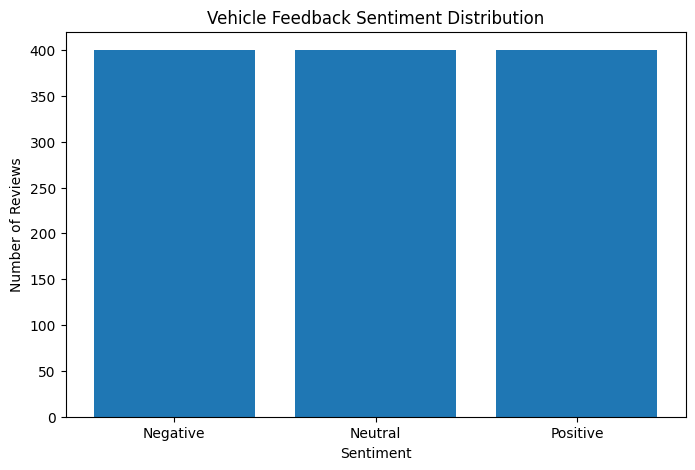

In [6]:
# ============================================================
# CELL 6 — Visualize Sentiment Class Distribution
# ============================================================

class_counts = (
    feedback_df["sentiment"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    CLASS_NAMES,
    class_counts.values
)

plt.title(
    "Vehicle Feedback Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [7]:
# ============================================================
# CELL 7 — Text Cleaning Function
# ============================================================

def clean_text(text):
    """
    Convert text to lowercase and retain alphabetic words.
    """

    text = text.lower()

    text = re.sub(
        r"[^a-z\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


feedback_df["clean_review"] = (
    feedback_df["review"]
    .apply(clean_text)
)

print("Original:")
print(feedback_df.loc[0, "review"])

print("\nCleaned:")
print(feedback_df.loc[0, "clean_review"])

Original:
poor fuel economy

Cleaned:
poor fuel economy


In [8]:
# ============================================================
# CELL 8 — Tokenize Reviews
# ============================================================

def tokenize(text):
    return text.split()


feedback_df["tokens"] = (
    feedback_df["clean_review"]
    .apply(tokenize)
)

print("Example tokens:")

print(
    feedback_df.loc[0, "tokens"]
)

Example tokens:
['poor', 'fuel', 'economy']


In [9]:
# ============================================================
# CELL 9 — Build Vocabulary
# ============================================================

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

counter = Counter()

for tokens in feedback_df["tokens"]:
    counter.update(tokens)

# Special tokens first
word_to_idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

# Add words to vocabulary
for word, frequency in counter.most_common():

    if word not in word_to_idx:

        word_to_idx[word] = (
            len(word_to_idx)
        )

idx_to_word = {
    idx: word
    for word, idx in word_to_idx.items()
}

VOCAB_SIZE = len(word_to_idx)

print("Vocabulary size:", VOCAB_SIZE)

print("\nFirst 20 vocabulary entries:")

for idx, word in list(
    idx_to_word.items()
)[:20]:

    print(
        f"{idx:3d} : {word}"
    )

Vocabulary size: 122

First 20 vocabulary entries:
  0 : <PAD>
  1 : <UNK>
  2 : the
  3 : is
  4 : service
  5 : infotainment
  6 : vehicle
  7 : and
  8 : engine
  9 : performance
 10 : system
 11 : quality
 12 : was
 13 : has
 14 : maintenance
 15 : features
 16 : cabin
 17 : seats
 18 : feels
 19 : very


In [11]:


# CODE CELL 10 — Encode and Pad Sequences
# ============================================================
# CELL 10 — Convert Tokens to Integer Sequences
# ============================================================

MAX_LEN = 12

def encode_tokens(tokens):
    return [
        word_to_idx.get(
            token,
            word_to_idx[UNK_TOKEN]
        )
        for token in tokens
    ]


def pad_sequence(
    sequence,
    max_len=MAX_LEN
):
    """
    Truncate long sequences and
    post-pad short sequences.
    """

    sequence = sequence[:max_len]

    padded = sequence + [
        word_to_idx[PAD_TOKEN]
    ] * (
        max_len - len(sequence)
    )

    return padded


encoded_sequences = (
    feedback_df["tokens"]
    .apply(encode_tokens)
    .apply(pad_sequence)
)

X = np.array(
    encoded_sequences.tolist(),
    dtype=np.int64
)

y = feedback_df[
    "sentiment"
].values.astype(np.int64)

print("Input tensor shape:", X.shape)
print("Target shape:", y.shape)

Input tensor shape: (1200, 12)
Target shape: (1200,)


In [12]:
# ============================================================
# CELL 11 — Inspect Token-to-Index Conversion
# ============================================================

sample_index = 0

print("Original review:")
print(
    feedback_df.loc[
        sample_index,
        "review"
    ]
)

print("\nTokens:")
print(
    feedback_df.loc[
        sample_index,
        "tokens"
    ]
)

print("\nEncoded + padded sequence:")
print(
    X[sample_index]
)

print("\nDecoded sequence:")

decoded_words = [
    idx_to_word[idx]
    for idx in X[sample_index]
]

print(decoded_words)

Original review:
poor fuel economy

Tokens:
['poor', 'fuel', 'economy']

Encoded + padded sequence:
[20 27 43  0  0  0  0  0  0  0  0  0]

Decoded sequence:
['poor', 'fuel', 'economy', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


In [13]:
# ============================================================
# CELL 12 — Train / Validation / Test Split
# ============================================================

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=SEED,
        stratify=y
    )
)

# Second split:
# 75% train, 25% validation of train+validation
X_train, X_val, y_train, y_val = (
    train_test_split(
        X_train_val,
        y_train_val,
        test_size=0.25,
        random_state=SEED,
        stratify=y_train_val
    )
)

print("Training set  :", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set      :", X_test.shape)

Training set  : (720, 12)
Validation set: (240, 12)
Test set      : (240, 12)


In [14]:
# ============================================================
# CELL 13 — PyTorch Dataset Class
# ============================================================

class VehicleFeedbackDataset(Dataset):

    def __init__(
        self,
        sequences,
        labels
    ):

        self.sequences = torch.tensor(
            sequences,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, index):

        return (
            self.sequences[index],
            self.labels[index]
        )


train_dataset = VehicleFeedbackDataset(
    X_train,
    y_train
)

val_dataset = VehicleFeedbackDataset(
    X_val,
    y_val
)

test_dataset = VehicleFeedbackDataset(
    X_test,
    y_test
)

print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

Training samples: 720
Validation samples: 240
Test samples: 240


In [15]:
# ============================================================
# CELL 14 — Create PyTorch DataLoaders
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)

sample_batch = next(
    iter(train_loader)
)

sample_sequences, sample_labels = (
    sample_batch
)

print(
    "Sequence batch shape:",
    sample_sequences.shape
)

print(
    "Label batch shape:",
    sample_labels.shape
)

Batch size: 32
Sequence batch shape: torch.Size([32, 12])
Label batch shape: torch.Size([32])


In [16]:
# ============================================================
# CELL 15 — Bidirectional LSTM Model
# ============================================================

class BiLSTMSentimentClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=64,
        hidden_dim=64,
        num_classes=3,
        padding_idx=0
    ):

        super().__init__()

        # ----------------------------------------------------
        # Word Embedding
        # ----------------------------------------------------

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        # ----------------------------------------------------
        # Bidirectional LSTM
        # ----------------------------------------------------

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # ----------------------------------------------------
        # Classification Layer
        #
        # Bi-LSTM output size = hidden_dim * 2
        # ----------------------------------------------------

        self.dropout = nn.Dropout(0.30)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )

    def forward(self, x):

        # Shape:
        # batch × sequence length
        embedded = self.embedding(x)

        # Shape:
        # batch × sequence length × embedding_dim
        lstm_output, (hidden, cell) = (
            self.lstm(embedded)
        )

        # hidden shape:
        # num_directions × batch × hidden_dim
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        # Concatenate forward and backward states
        combined = torch.cat(
            (
                forward_hidden,
                backward_hidden
            ),
            dim=1
        )

        combined = self.dropout(
            combined
        )

        logits = self.fc(
            combined
        )

        return logits

In [17]:
# ============================================================
# CELL 16 — Initialize Bi-LSTM Model
# ============================================================

EMBEDDING_DIM = 64
HIDDEN_DIM = 64
NUM_CLASSES = 3

model = BiLSTMSentimentClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    padding_idx=word_to_idx[PAD_TOKEN]
)

model = model.to(device)

print(model)

BiLSTMSentimentClassifier(
  (embedding): Embedding(122, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [18]:
# ============================================================
# CELL 17 — Model Parameter Count
# ============================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Total parameters    :",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

Total parameters    : 74755
Trainable parameters: 74755


In [19]:
# ============================================================
# CELL 18 — Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 10

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print("Learning rate : 0.001")
print("Epochs        :", EPOCHS)

Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.001
Epochs        : 10


In [20]:
# ============================================================
# CELL 19 — Training and Validation Functions
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in loader:

        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(
            sequences
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * sequences.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    average_loss = (
        total_loss / total
    )

    accuracy = (
        correct / total
    )

    return average_loss, accuracy


def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for sequences, labels in loader:

            sequences = sequences.to(device)
            labels = labels.to(device)

            logits = model(
                sequences
            )

            loss = criterion(
                logits,
                labels
            )

            total_loss += (
                loss.item()
                * sequences.size(0)
            )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    average_loss = (
        total_loss / total
    )

    accuracy = (
        correct / total
    )

    return average_loss, accuracy

In [21]:
# ============================================================
# CELL 20 — Train the Bidirectional LSTM
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
    )

    val_loss, val_accuracy = (
        evaluate(
            model,
            val_loader,
            criterion,
            device
        )
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01/10 | Train Loss: 1.0030 | Train Acc: 0.6222 | Val Loss: 0.8564 | Val Acc: 0.8917
Epoch 02/10 | Train Loss: 0.6192 | Train Acc: 0.9514 | Val Loss: 0.3466 | Val Acc: 0.9125
Epoch 03/10 | Train Loss: 0.2065 | Train Acc: 0.9750 | Val Loss: 0.0788 | Val Acc: 1.0000
Epoch 04/10 | Train Loss: 0.0360 | Train Acc: 1.0000 | Val Loss: 0.0169 | Val Acc: 0.9958
Epoch 05/10 | Train Loss: 0.0079 | Train Acc: 1.0000 | Val Loss: 0.0127 | Val Acc: 0.9958
Epoch 06/10 | Train Loss: 0.0041 | Train Acc: 1.0000 | Val Loss: 0.0152 | Val Acc: 0.9958
Epoch 07/10 | Train Loss: 0.0026 | Train Acc: 1.0000 | Val Loss: 0.0140 | Val Acc: 0.9958
Epoch 08/10 | Train Loss: 0.0019 | Train Acc: 1.0000 | Val Loss: 0.0142 | Val Acc: 0.9958
Epoch 09/10 | Train Loss: 0.0016 | Train Acc: 1.0000 | Val Loss: 0.0145 | Val Acc: 0.9958
Epoch 10/10 | Train Loss: 0.0013 | Train Acc: 1.0000 | Val Loss: 0.0148 | Val Acc: 0.9958


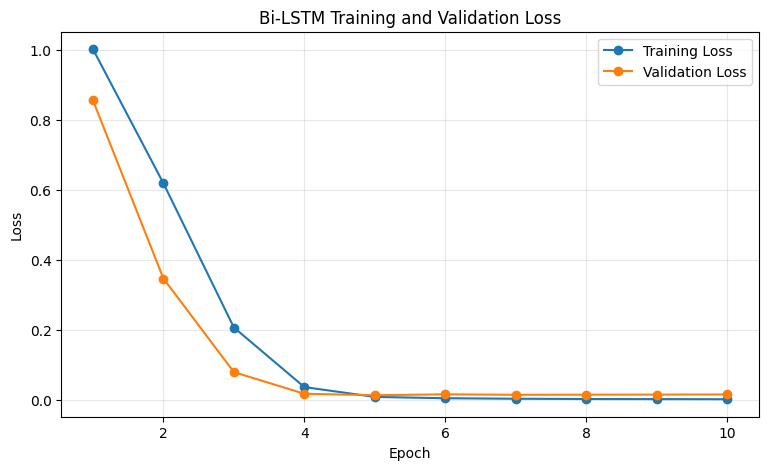

In [22]:
# ============================================================
# CELL 21 — Plot Training and Validation Loss
# ============================================================

epochs_range = range(
    1,
    EPOCHS + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "Bi-LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

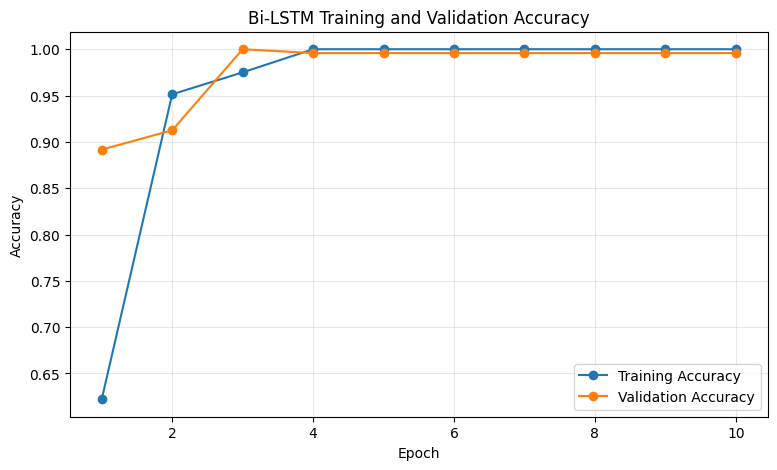

In [23]:
# ============================================================
# CELL 22 — Plot Training and Validation Accuracy
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Bi-LSTM Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [24]:
# ============================================================
# CELL 23 — Evaluate Model on Test Set
# ============================================================

test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

Test Loss     : 0.0009
Test Accuracy : 1.0000


In [25]:
# ============================================================
# CELL 24 — Generate Test Predictions
# ============================================================

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for sequences, labels in test_loader:

        sequences = sequences.to(device)

        logits = model(
            sequences
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_predictions = np.array(
    all_predictions
)

all_labels = np.array(
    all_labels
)

print(
    "Predictions generated:",
    len(all_predictions)
)

Predictions generated: 240


In [26]:
# ============================================================
# CELL 25 — Classification Report
# ============================================================

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

              precision    recall  f1-score   support

    Negative     1.0000    1.0000    1.0000        80
     Neutral     1.0000    1.0000    1.0000        80
    Positive     1.0000    1.0000    1.0000        80

    accuracy                         1.0000       240
   macro avg     1.0000    1.0000    1.0000       240
weighted avg     1.0000    1.0000    1.0000       240



<Figure size 700x700 with 0 Axes>

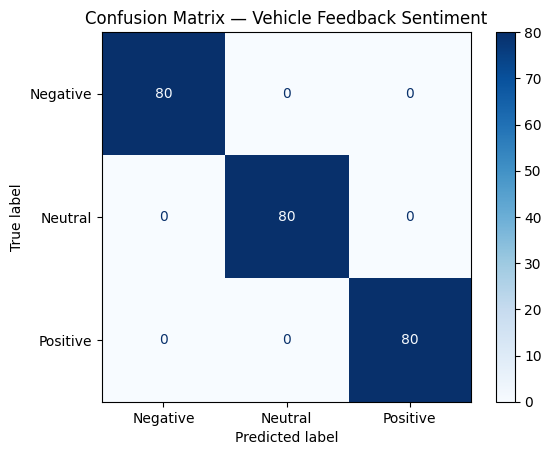

In [27]:
# ============================================================
# CELL 26 — Confusion Matrix
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Confusion Matrix — Vehicle Feedback Sentiment"
)

plt.show()

In [28]:
# ============================================================
# CELL 27 — Sentiment Prediction Function
# ============================================================

def predict_sentiment(
    text,
    model,
    tokenizer_map,
    max_len=MAX_LEN
):

    model.eval()

    # Clean text
    cleaned = clean_text(text)

    # Tokenize
    tokens = cleaned.split()

    # Convert words to IDs
    sequence = [
        tokenizer_map.get(
            token,
            tokenizer_map[UNK_TOKEN]
        )
        for token in tokens
    ]

    # Pad
    sequence = pad_sequence(
        sequence,
        max_len=max_len
    )

    # Convert to tensor
    input_tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        logits = model(
            input_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

    return (
        CLASS_NAMES[predicted_class],
        probabilities[0].cpu().numpy()
    )

In [29]:
# ============================================================
# CELL 28 — Inference on New Vehicle Reviews
# ============================================================

sample_reviews = [

    "the vehicle has excellent mileage and a very smooth ride",

    "the engine performance is average and meets expectations",

    "the brakes are weak and the dealership service was terrible",

    "the cabin is comfortable and the infotainment works perfectly",

    "the vehicle has frequent electrical problems and poor quality"
]

for review in sample_reviews:

    sentiment, probabilities = (
        predict_sentiment(
            review,
            model,
            word_to_idx
        )
    )

    print("\nReview:")
    print(review)

    print(
        f"Prediction: {sentiment}"
    )

    print(
        f"Negative: {probabilities[0]:.4f}"
    )

    print(
        f"Neutral : {probabilities[1]:.4f}"
    )

    print(
        f"Positive: {probabilities[2]:.4f}"
    )


Review:
the vehicle has excellent mileage and a very smooth ride
Prediction: Positive
Negative: 0.1002
Neutral : 0.3421
Positive: 0.5577

Review:
the engine performance is average and meets expectations
Prediction: Neutral
Negative: 0.0002
Neutral : 0.9996
Positive: 0.0002

Review:
the brakes are weak and the dealership service was terrible
Prediction: Neutral
Negative: 0.0081
Neutral : 0.9900
Positive: 0.0020

Review:
the cabin is comfortable and the infotainment works perfectly
Prediction: Neutral
Negative: 0.0156
Neutral : 0.8711
Positive: 0.1133

Review:
the vehicle has frequent electrical problems and poor quality
Prediction: Negative
Negative: 0.8927
Neutral : 0.1024
Positive: 0.0049


In [30]:
# ============================================================
# CELL 29 — Inference Results as a DataFrame
# ============================================================

inference_results = []

for review in sample_reviews:

    sentiment, probabilities = (
        predict_sentiment(
            review,
            model,
            word_to_idx
        )
    )

    inference_results.append({
        "Review": review,
        "Predicted Sentiment": sentiment,
        "Negative Probability": round(
            float(probabilities[0]),
            4
        ),
        "Neutral Probability": round(
            float(probabilities[1]),
            4
        ),
        "Positive Probability": round(
            float(probabilities[2]),
            4
        )
    })


inference_df = pd.DataFrame(
    inference_results
)

display(inference_df)

,Review,Predicted Sentiment,Negative Probability,Neutral Probability,Positive Probability
0,the vehicle has excellent mileage and a very s...,Positive,0.1002,0.3421,0.5577
1,the engine performance is average and meets ex...,Neutral,0.0002,0.9996,0.0002
2,the brakes are weak and the dealership service...,Neutral,0.0081,0.9900,0.0020
3,the cabin is comfortable and the infotainment ...,Neutral,0.0156,0.8711,0.1133
4,the vehicle has frequent electrical problems a...,Negative,0.8927,0.1024,0.0049


## Conclusion

This experiment demonstrated how Recurrent Deep Learning can be applied to Automotive Voice of Customer analysis.

A Bidirectional LSTM was used to process vehicle feedback from both forward and backward directions, allowing the model to capture contextual relationships within customer reviews.

The complete NLP pipeline transformed unstructured automotive feedback into numerical sequences, learned word embeddings, processed the sequences using a Bi-LSTM, and classified the feedback into Positive, Neutral, and Negative categories.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Softmax probabilities were also generated for new vehicle reviews, demonstrating how the trained model can be used for practical sentiment inference.

Such a system can assist automotive organizations in monitoring customer satisfaction, identifying recurring product issues, and analyzing dealership service feedback at scale.